# Algorytmika i matematyka uczenia maszynowego 
## Laboratorium 10

### Zadanie 1

W okolicy znajdują się **trzy obozy**. Nie znamy liczby uczestników, ale posiadamy dane o ich zamówieniach na dwa produkty:

- **woda** (w litrach),  
- **kawa** (w sztukach).


1. Wyświetl dane na wykresie punktowym, gdzie:
   - oś **X** przedstawia zamówienia na **wodę**,
   - oś **Y** przedstawia zamówienia na **kawę**.  
   Każdy obóz powinien być reprezentowany jako punkt na wykresie.

2. **Dodaj linie** prowadzące z punktu **(0, 0)** do każdego z punktów reprezentujących obozy.

3. **Oblicz** między każdą parą obozów:
   - **odległości [Euklidesowe](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.euclidean.html)**,
   - **odległości [kosinusowe](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.cosine.html)**.

4. **Wskaż parę obozów najbardziej podobnych do siebie** (na podstawie jednej lub obu metryk).

Dane wejściowe:


| Nazwa obozu     | Zamówienia na wodę (w l.) | Zamówienia na kawę (w szt.) |
| :---            | ---                       | --- |
| Obóz sportowy 1 | 200 | 25  |
| Obóz sportowy 2 | 900 | 80  |
| Obóz szachowy   | 300 | 120 |



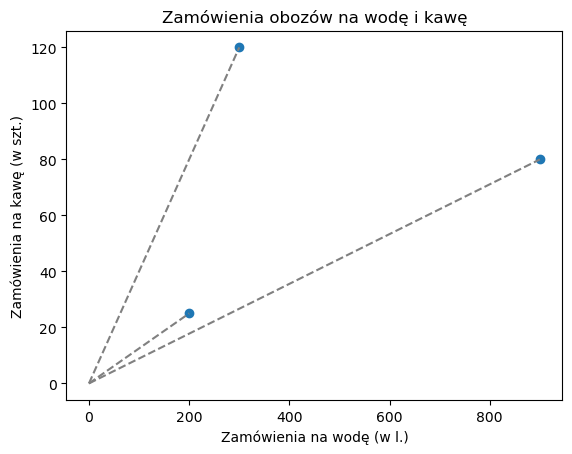

Odległości Euklidesa pomiędzy obozami:
Odl. Euklidesa dla Obozu 1 i Obozu 2: 702.16
Odl. Euklidesa dla Obozu 1 i Obozu Szachowego: 137.93
Odl. Euklidesa dla Obozu 2 i Obozu Szachowego: 601.33

Odległości kosinusowe pomiędzy obozami:
Odl. kosinusowa dla Obozu 1 i Obozu 2: 0.0006
Odl. kosinusowa dla Obozu 1 i Obozu Szachowego: 0.0326
Odl. kosinusowa dla Obozu 2 i Obozu Szachowego: 0.0423


In [19]:
import math
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial import distance

waters = [200, 900, 300]
coffee = [25, 80, 120]

plt.scatter(waters, coffee)
for w, c in zip(waters, coffee):
    plt.plot([0, w], [0, c], linestyle='--', color='gray')
plt.xlabel('Zamówienia na wodę (w l.)')
plt.ylabel('Zamówienia na kawę (w szt.)')
plt.title('Zamówienia obozów na wodę i kawę')
plt.show()

print("Odległości Euklidesa pomiędzy obozami:")
ab = distance.euclidean([waters[0], coffee[0]], [waters[1], coffee[1]])
print(f'Odl. Euklidesa dla Obozu 1 i Obozu 2: {ab:.2f}')
ac = distance.euclidean([waters[0], coffee[0]], [waters[2], coffee[2]])
print(f'Odl. Euklidesa dla Obozu 1 i Obozu Szachowego: {ac:.2f}')
bc = distance.euclidean([waters[1], coffee[1]], [waters[2], coffee[2]])
print(f'Odl. Euklidesa dla Obozu 2 i Obozu Szachowego: {bc:.2f}')

orders = np.array([waters, coffee]).T

def cosine_distance(a, b):
    dot_product = sum(x * y for x, y in zip(a, b))
    norm_a = math.sqrt(sum(x**2 for x in a))
    norm_b = math.sqrt(sum(y**2 for y in b))
    cosine_sim = dot_product / (norm_a * norm_b)
    return 1 - cosine_sim

print("\nOdległości kosinusowe pomiędzy obozami:")
ab_cosine = cosine_distance(orders[0], orders[1])
print(f'Odl. kosinusowa dla Obozu 1 i Obozu 2: {ab_cosine:.4f}')
ac_cosine = cosine_distance([waters[0], coffee[0]], [waters[2], coffee[2]])
print(f'Odl. kosinusowa dla Obozu 1 i Obozu Szachowego: {ac_cosine:.4f}')
bc_cosine = cosine_distance([waters[1], coffee[1]], [waters[2], coffee[2]])
print(f'Odl. kosinusowa dla Obozu 2 i Obozu Szachowego: {bc_cosine:.4f}')


Najbardziej podobne są obozy 1 i 2 wg odległości cosinusowej. Dla odl. euklidesa najpodobniejsze są obóz 1 i szachowy.

### Zadanie 2

#### A)

Mamy dane dotyczące kilku parków narodowych. Chcielibyśmy wykorzystać poznane w poprzednim zadaniu miary podobieństwa w celu odnalezienia najbardziej podobnych parków na podstawie pewnych szacunkowych pomiarów liczby drzew (iglastych i liściastych) oraz populacji kilku gatunków zwierząt. 

  

1. Dla każdej pary parków oblicz odległość Euklidesową i kosinusową. 
2. Wskaż parę najbardziej podobnych parków (dla każdej metryki osobno).  
4. Na podstawie uzyskanych wyników odpowiedz na pytanie która miara lepiej oddaje podobieństwo między parkami? Uzasadnij swoją opinię.
5. Znajdź park najbardziej podobny do Tatrzańskiego Parku Narodowego? 

Szacunkowe dane:

| Nazwa                                       | Liczba drzew iglastych | Liczba drzew liściastych | Liczba dzików | Liczba wilków | Liczba niedźwiedzi | Liczba jeleni |
| ---                                         | ---      | ---    |--- |--- | --- | ---  |
|Tatrzański Park Narodowy (Polska)            |   1000000|  200000|  90|  75|   50|  1200|
|Białowieski Park Narodowy (Polska)           |    250000| 1100000| 250|  40|    0|  1000|
|Yellowstone National Park (Stany Zjednoczone)|  30000000| 1000000|   0| 120| 1200| 30000|
|Banff National Park (Kanada)                 | 110000000| 7000000|   0|  40|  120|  5000|
|Nadbajkalski Park Narodowy (Rosja)           |   8000000| 2100000| 700| 550|  225|  6000|

#### B)

Co można zrobić, aby odległość Euklidesa zwracała wyniki podobne do kosinusowej? Wykonaj zadanie ponownie uzyskując inne (być może "lepsze") wyniki dla metryki Euklidesa niż w podzadaniu A.

In [32]:
from itertools import combinations

national_parks = {
    "Tatrzański Park Narodowy": [1_000_000, 200_000, 90, 75, 50, 1200],
    "Białowieski Park Narodowy": [250_000, 1_100_000, 250, 40, 0, 1000],
    "Yellowstone National Park": [30_000_000, 1_000_000, 0, 120, 1200, 30000],
    "Banff National Park": [110_000_000, 7_000_000, 0, 100, 120, 5000],
    "Nadbajkalski Park Narodowy": [8_000_000, 2_100_000, 700, 550, 225, 6000]
}

park_names = list(national_parks.keys())
park_vectors = list(national_parks.values())

print("Odległości Euklidesowe pomiędzy parkami narodowymi:".upper())
euclidean_distances = {}
for (i, vec1), (j, vec2) in combinations(enumerate(park_vectors), 2):
    dist = distance.euclidean(vec1, vec2)
    pair = (park_names[i], park_names[j])
    euclidean_distances[pair] = dist

sorted_euclidean = sorted(euclidean_distances.items(), key=lambda x: x[1])
for (park1, park2), dist in sorted_euclidean[:5]:
    print(f"{park1} <-> {park2}: {dist:.2f}")

print("\nNajbardziej podobne pary parków:")
for (park1, park2), dist in sorted_euclidean[:1]:
    print(f"{park1} i {park2} są najbardziej podobne: {dist:.2f}")

print("\nOdległości kosinusowe pomiędzy parkami narodowymi:".upper())
cosine_distances = {}
for (i, vec1), (j, vec2) in combinations(enumerate(park_vectors), 2):
    dist = cosine_distance(vec1, vec2)
    pair = (park_names[i], park_names[j])
    cosine_distances[pair] = dist
sorted_cosine = sorted(cosine_distances.items(), key=lambda x: x[1])
for (park1, park2), dist in sorted_cosine[:5]:
    print(f"{park1} <-> {park2}: {dist:.4f}")
print("\nNajbardziej podobne pary parków (kosinus):")
for (park1, park2), dist in sorted_cosine[:1]:
    print(f"{park1} i {park2} są najbardziej podobne (kosinus): {dist:.4f}")

tatra_name = "Tatrzański Park Narodowy"

euclid_similar = [(pair, dist) for pair, dist in euclidean_distances.items() if tatra_name in pair and pair[0] != pair[1]]
euclid_similar = sorted(euclid_similar, key=lambda x: x[1])
closest_euclid = [p for p in euclid_similar if tatra_name != p[0]][0] if tatra_name == euclid_similar[0][0][1] else euclid_similar[0]
other_park_euclid = [name for name in closest_euclid[0] if name != tatra_name][0]
print(f"\nNajbardziej podobny park do Tatrzańskiego wg odległości Euklidesa: {other_park_euclid} ({closest_euclid[1]:.2f})")

cosine_similar = [(pair, dist) for pair, dist in cosine_distances.items() if tatra_name in pair and pair[0] != pair[1]]
cosine_similar = sorted(cosine_similar, key=lambda x: x[1])
closest_cosine = [p for p in cosine_similar if tatra_name != p[0]][0] if tatra_name == cosine_similar[0][0][1] else cosine_similar[0]
other_park_cosine = [name for name in closest_cosine[0] if name != tatra_name][0]
print(f"Najbardziej podobny park do Tatrzańskiego wg odległości kosinusowej: {other_park_cosine} ({closest_cosine[1]:.4f})")   


ODLEGŁOŚCI EUKLIDESOWE POMIĘDZY PARKAMI NARODOWYMI:
Tatrzański Park Narodowy <-> Białowieski Park Narodowy: 1171537.48
Tatrzański Park Narodowy <-> Nadbajkalski Park Narodowy: 7253276.75
Białowieski Park Narodowy <-> Nadbajkalski Park Narodowy: 7814251.44
Yellowstone National Park <-> Nadbajkalski Park Narodowy: 22027495.95
Tatrzański Park Narodowy <-> Yellowstone National Park: 29011046.70

Najbardziej podobne pary parków:
Tatrzański Park Narodowy i Białowieski Park Narodowy są najbardziej podobne: 1171537.48

ODLEGŁOŚCI KOSINUSOWE POMIĘDZY PARKAMI NARODOWYMI:
Yellowstone National Park <-> Banff National Park: 0.0005
Tatrzański Park Narodowy <-> Nadbajkalski Park Narodowy: 0.0018
Tatrzański Park Narodowy <-> Banff National Park: 0.0089
Tatrzański Park Narodowy <-> Yellowstone National Park: 0.0134
Banff National Park <-> Nadbajkalski Park Narodowy: 0.0186

Najbardziej podobne pary parków (kosinus):
Yellowstone National Park i Banff National Park są najbardziej podobne (kosinus): 0.000

### Zadanie 3 

Plik `glosowanie.csv` zawiera dane o posłach, którzy głosowali **ZA** w głosowaniach parlamentarnych. Plik zawiera następujące informacje:
- imię i nazwisko posła,
- przynależność do klubu poselskiego,
- numer posiedzenia i numer głosowania.

Zakres danych obejmuje głosowania od 3. do 35. posiedzenia**.

1. Przekształć dane do formy, w której każdy klub jest reprezentowany jako wektor.
2. Oblicz miarę podobieństwa między klubami.
3. Wskaż:
   - parę klubów głosujących najbardziej podobnie,
   - parę klubów głosujących najmniej podobnie,
   - klub, który głosuje najbardziej odmiennie od pozostałych (tj. ma największą sumę odległości do wszystkich innych klubów).


> Uwaga! Uwzględnij, że niektóre kluby poselskie zmieniły nazwę (zgrupuj je).
 
> Możesz postarać się usunąć mało istotne głosowania np. "Wniosek o przerwę"

In [ ]:
# UZUPEŁNIJ